## What is the probability that people score higher in agreeableness than extraversion according to the results of Big Five Personality Test by Open Source Psychometrics Project?

<img src="img/AgreevsExtra.png" width=500/>

* Image icons from verywellmind.com

---

### **Introduction**

This analysis explores whether respondents are more likely to score higher in agreeableness than in extraversion using data from the Big Five Personality test. Comparing these two traits will allow us to dig deeper into how characterics in personality show up in a sample and find patterns that go beyond just looking at individual scores. Additionally, we can compare the global respondants to the results from our COMM 3180 class data to see whether the trends that appear in the wider population are reflected within our own group. Overall, this comparison helps us think about generalizability, whether findings from a large dataset align with a smaller, more specific sample. 

To put it simply, the story that this data tells encourages us to reflect on how our class compares to respondents worldwide.

##### TO BE CLEAR!
The analysis being done to answer this questions is looking at the percentiles of the Big 5 personality traits, NOT raw scores.

---

* All of the data analysis being conducted under "Preliminary Data" is to set up for the main analysis that will answer the main question.
* Scroll past preliminary data for the analysis.

#### Preliminary Data: Unscored

---

In [308]:
import pandas as pd
import re
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

In [309]:
big5_df = pd.read_csv('data/openpsych_data.csv', sep='\t')

In [310]:
big5_df.columns

Index(['race', 'age', 'engnat', 'gender', 'hand', 'source', 'country', 'E1',
       'E2', 'E3', 'E4', 'E5', 'E6', 'E7', 'E8', 'E9', 'E10', 'N1', 'N2', 'N3',
       'N4', 'N5', 'N6', 'N7', 'N8', 'N9', 'N10', 'A1', 'A2', 'A3', 'A4', 'A5',
       'A6', 'A7', 'A8', 'A9', 'A10', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7',
       'C8', 'C9', 'C10', 'O1', 'O2', 'O3', 'O4', 'O5', 'O6', 'O7', 'O8', 'O9',
       'O10'],
      dtype='str')

In [311]:
big5_country_df = big5_df['country']

In [312]:
big5_df['country'].nunique()

158

In [313]:
questions = '''
E1	I am the life of the party.
E2	I don't talk a lot.
E3	I feel comfortable around people.
E4	I keep in the background.
E5	I start conversations.
E6	I have little to say.
E7	I talk to a lot of different people at parties.
E8	I don't like to draw attention to myself.
E9	I don't mind being the center of attention.
E10	I am quiet around strangers.
N1	I get stressed out easily.
N2	I am relaxed most of the time.
N3	I worry about things.
N4	I seldom feel blue.
N5	I am easily disturbed.
N6	I get upset easily.
N7	I change my mood a lot.
N8	I have frequent mood swings.
N9	I get irritated easily.
N10	I often feel blue.
A1	I feel little concern for others.
A2	I am interested in people.
A3	I insult people.
A4	I sympathize with others' feelings.
A5	I am not interested in other people's problems.
A6	I have a soft heart.
A7	I am not really interested in others.
A8	I take time out for others.
A9	I feel others' emotions.
A10	I make people feel at ease.
C1	I am always prepared.
C2	I leave my belongings around.
C3	I pay attention to details.
C4	I make a mess of things.
C5	I get chores done right away.
C6	I often forget to put things back in their proper place.
C7	I like order.
C8	I shirk my duties.
C9	I follow a schedule.
C10	I am exacting in my work.
O1	I have a rich vocabulary.
O2	I have difficulty understanding abstract ideas.
O3	I have a vivid imagination.
O4	I am not interested in abstract ideas.
O5	I have excellent ideas.
O6	I do not have a good imagination.
O7	I am quick to understand things.
O8	I use difficult words.
O9	I spend time reflecting on things.
O10	I am full of ideas.
'''


In [314]:
big5_questions_df = pd.DataFrame([item.split('\t') for item in questions.splitlines() if item>''])

In [315]:
big5_questions_df

,0,1
0,E1,I am the life of the party.
1,E2,I don't talk a lot.
2,E3,I feel comfortable around people.
3,E4,I keep in the background.
4,E5,I start conversations.
5,E6,I have little to say.
6,E7,I talk to a lot of different people at parties.
7,E8,I don't like to draw attention to myself.
8,E9,I don't mind being the center of attention.
9,E10,I am quiet around strangers.


In [316]:
factor_map = { 1: 'E', 
               2: 'A',
               3: 'C',
               4: 'N',
               5: 'O' }

In [317]:
ipip_df = pd.read_html('big5_questions.html', header=0)[0]
ipip_df = ipip_df.rename(columns={'Unnamed: 1': 'text', 'Unnamed: 7': 'factor_and_direction'})[['text','factor_and_direction']]
ipip_df[['factor','direction']]=ipip_df['factor_and_direction'].str.extract(r'([1-5])(.)')
ipip_df['category']=ipip_df['factor'].astype(int).map(factor_map)

In [318]:
ipip_df = ipip_df.assign(number=np.repeat(np.arange(1,11),5))
ipip_df = ipip_df.assign(qcode=ipip_df['category'].str.cat(ipip_df['number'].astype(str)))   

In [319]:
neg_items = ipip_df.query('direction=="-"')['qcode']
neg_items

1      A1
3      N1
5      E2
7      C2
9      O2
11     A3
13     N3
15     E4
17     C4
19     O4
21     A5
23     N5
25     E6
27     C6
28     N6
29     O6
31     A7
33     N7
35     E8
37     C8
38     N8
43     N9
45    E10
48    N10
Name: qcode, dtype: str

---

#### Preliminary Data: Scored

---

In [320]:
big5_scored_df = pd.read_csv('data/openpsych_data_scored.csv')

In [321]:
big5_scored_df.shape

(19719, 69)

In [322]:
big5_scored_df.columns

Index(['race', 'age', 'engnat', 'gender', 'hand', 'source', 'country', 'E1',
       'E2', 'E3', 'E4', 'E5', 'E6', 'E7', 'E8', 'E9', 'E10', 'N1', 'N2', 'N3',
       'N4', 'N5', 'N6', 'N7', 'N8', 'N9', 'N10', 'A1', 'A2', 'A3', 'A4', 'A5',
       'A6', 'A7', 'A8', 'A9', 'A10', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7',
       'C8', 'C9', 'C10', 'O1', 'O2', 'O3', 'O4', 'O5', 'O6', 'O7', 'O8', 'O9',
       'O10', 'race_cat', 'gender_cat', 'O', 'C', 'E', 'A', 'N', 'E_pct',
       'A_pct', 'C_pct', 'N_pct', 'O_pct'],
      dtype='str')

In [323]:
big5_scored_df[['O','C','E','A','N','E_pct','A_pct', 'C_pct', 'N_pct', 'O_pct']]

,O,C,E,A,N,E_pct,A_pct,C_pct,N_pct,O_pct
0,43,47,44,46,49,93,85,97,99,70
1,26,42,22,35,29,20,27,86,50,2
2,45,49,35,38,14,68,42,98,3,81
3,41,26,22,37,17,20,37,16,8,58
4,34,34,34,44,30,64,76,52,54,20
...,...,...,...,...,...,...,...,...,...,...
19714,35,36,21,42,19,18,65,62,13,25
19715,30,32,25,36,39,30,32,42,86,8
19716,37,23,21,26,10,18,5,7,0,35
19717,42,43,21,38,20,18,42,89,16,64


In [324]:
cat_cols = {
    cat : [f'{cat}{n+1}' for n in range(10)] 
    for cat in ('O','C','E','A','N') 
}

In [325]:
cat_cols

{'O': ['O1', 'O2', 'O3', 'O4', 'O5', 'O6', 'O7', 'O8', 'O9', 'O10'],
 'C': ['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10'],
 'E': ['E1', 'E2', 'E3', 'E4', 'E5', 'E6', 'E7', 'E8', 'E9', 'E10'],
 'A': ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10'],
 'N': ['N1', 'N2', 'N3', 'N4', 'N5', 'N6', 'N7', 'N8', 'N9', 'N10']}

In [326]:
for cat, cols in cat_cols.items():
    big5_scored_df[cat]=big5_scored_df[cols].sum(axis=1)

---

# Analysis 

**STEPS**
1. Find a random sample of 10 countries
2. Filter the data to only show the sampled countried 
3. Calculate the probability that the individuals in the sampled countries are greater in agreeableness than extroversion
4. Visualize the findings

In [327]:
unique = big5_df["country"].drop_duplicates()
unique

0        US
2        PK
3        RO
7        IN
10       IT
         ..
16741    ZM
16914    PY
16962    UZ
18180    TC
19682    KG
Name: country, Length: 159, dtype: str

* Here we have all of the abbreviations of countries that are represented by the people who took the survey

In [328]:
country_sample = unique.sample(n=10, random_state=40)
country_sample

246      AR
6254     LS
10920    GY
16       FR
5327     KH
413      HK
7419     MP
620      LK
228      DE
1980     ZW
Name: country, dtype: str

Here is the random sample of the 10 countries that will be examined in this analysis. We can look at the data from the survey respondants from these listed countries to see each individuals percentile score in agreeableness and extraversion. This randomization also ensures that the data is diverse because cultural norms may impact/skew how people view their own personaility

In [329]:
big5_sample_df = big5_df[big5_df['country'].isin(country_sample)]
big5_sample_df

,race,age,engnat,gender,hand,source,country,E1,E2,E3,...,O1,O2,O3,O4,O5,O6,O7,O8,O9,O10
16,13,19,1,2,1,2,FR,1,3,2,...,5,1,4,1,4,1,5,5,5,4
228,1,39,1,2,1,1,DE,1,3,2,...,4,2,2,2,3,4,4,4,4,3
240,3,15,2,2,2,1,DE,1,3,1,...,3,1,5,1,4,1,5,4,5,4
246,1,26,2,1,2,1,AR,2,1,4,...,5,1,5,1,5,1,4,5,2,4
387,3,28,2,1,1,1,DE,1,4,3,...,5,3,5,3,3,1,3,5,5,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19475,3,39,2,2,1,1,DE,3,1,4,...,5,1,5,1,5,1,5,5,5,5
19486,3,25,2,2,1,5,FR,2,4,4,...,4,1,5,1,5,1,5,4,5,5
19574,3,28,2,1,1,3,AR,2,5,3,...,5,2,5,1,3,1,4,4,5,3
19593,3,18,2,2,2,1,DE,1,2,2,...,5,1,2,2,4,4,5,3,3,2


In [330]:
big5_sample_scored = big5_scored_df[big5_scored_df['country'].isin(country_sample)]
big5_sample_scored

,race,age,engnat,gender,hand,source,country,E1,E2,E3,...,O,C,E,A,N,E_pct,A_pct,C_pct,N_pct,O_pct
16,13,19,1,2,1,2,FR,1,3,2,...,47,36,20,17,33,15,0,62,66,90
228,1,39,1,2,1,1,DE,1,3,2,...,34,28,19,39,24,13,48,23,30,20
240,3,15,2,2,2,1,DE,1,3,1,...,45,24,20,34,15,15,23,10,5,81
246,1,26,2,1,2,1,AR,2,5,4,...,45,46,38,35,27,77,27,95,42,81
387,3,28,2,1,1,1,DE,1,2,3,...,42,43,25,32,46,30,17,89,97,64
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19475,3,39,2,2,1,1,DE,3,5,4,...,50,41,42,49,42,88,96,83,92,98
19486,3,25,2,2,1,5,FR,2,2,4,...,48,35,21,42,34,18,65,57,70,93
19574,3,28,2,1,1,3,AR,2,1,3,...,43,36,19,34,21,13,23,62,19,70
19593,3,18,2,2,2,1,DE,1,4,2,...,35,39,24,23,40,27,3,76,88,25


* Each row in this dataset represents one respondant who did the Big Five Personality test which include their demographic information and personality results. The columns show the different variables age, gender, and country, along with both raw trait scores (O, C, E, A, N) and percentile rankings.
* Using these rows and columns, we can compare agreeableness and extraversion scores to understand whether people — in our sample and in our class — are more likely to rank higher in one trait than the other.

In [334]:
A_GT_E_prob = ((big5_sample_scored['A_pct'] > big5_sample_scored['E_pct']).mean())
print(f'The probability that people in the sample score higher in agreeableness than extraversion is {A_GT_E_prob}')
percent_A_GT_E_prob = ((A_GT_E_prob)*100)
print(f'Which is a {percent_A_GT_E_prob}%')

The probability that people in the sample score higher in agreeableness than extraversion is 0.43243243243243246
Which is a 43.24324324324324%


In [332]:
big5_sample_scored['A_GT_E_prob'] = big5_sample_scored['A_pct'] > big5_sample_scored['E_pct']

In [333]:
big5_sample_scored.groupby('country')['A_GT_E_prob'].mean()

country
AR    0.487805
DE    0.429319
FR    0.348837
GY    1.000000
HK    0.512195
KH    0.333333
LK    0.548387
LS    0.500000
MP    0.500000
ZW    1.000000
Name: A_GT_E_prob, dtype: float64

Here we find that in the overall sample the probaility that people score higher in agreeablness over extravesion is about 0.432. 

However, the probability results from the individual countries in the sample vary across the regions. For example, some countries such as Hong Kong and Sri Lanka have probabilities that are slightly above 0.5, which suggests that a small majority of respondents in those regions tend to score higher in agreeableness than extraversion. Contrarily, there are countries like France and Germany where the probabilty of scoring high in agreeableness is low. There are also a few countries that show values closer to 1.0, which may reflect smaller sample sizes rather than strong personality differences (which tells us be cauties when interpreting these probabilities). Overall, the variation across countries suggests that personality patterns are different worldwide and reinforces the need to compare the global trends with our class data to understand if our own results are representative of the larger pool.

---

### Looking at the other side (probability that the people in the sample socre higher on extraversion rather than agreeableness)

In [285]:
E_GT_A_prob = ((big5_sample_scored['E_pct'] > big5_sample_scored['A_pct']).mean())
print(f'The probability that people in the sample score higher in extraversion rather than agreeableness is {E_GT_A_prob}')
percent_E_GT_A_prob = (E_GT_A_prob*100)
print(f'Which is {percent_E_GT_A_prob}%')

The probability that people in the sample score higher in extraversion rather than agreeableness is 0.5563063063063063
Which is 55.63063063063063%


In [265]:
big5_sample_scored['E_GT_A_prob'] = big5_sample_scored['E_pct'] > big5_sample_scored['A_pct']

In [266]:
big5_sample_scored.groupby('country')['E_GT_A_prob'].mean()

country
AR    0.487805
DE    0.554974
FR    0.643411
GY    0.000000
HK    0.487805
KH    0.666667
LK    0.451613
LS    0.500000
MP    0.500000
ZW    0.000000
Name: E_GT_A_prob, dtype: float64

Text(0.5, 1.0, 'Probability of Higher Scores in Agreeableness vs Extraversion from Sampled Countries')

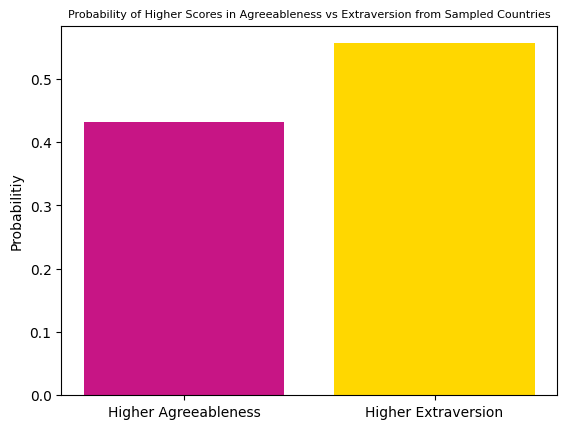

In [297]:
import matplotlib.pyplot as plt

labels = ['Higher Agreeableness', 'Higher Extraversion']
values = [A_GT_E_prob, E_GT_A_prob]

plt.bar(labels, values)
plt.bar(labels, values, color=['mediumvioletred', 'gold'])
plt.ylabel('Probabilitiy')
plt.title('Probability of Higher Scores in Agreeableness vs Extraversion from Sampled Countries',fontsize=8)

Here we find that the probability of scoring in a higher percentile of extraversion over agreeableness is about 0.556.

The bar chart compares the probability that respondents in the sampled countries score higher in agreeableness versus extraversion. The taller gold bar indicates that a larger proportion of individuals have higher extraversion percentiles than agreeableness percentiles. This means that within this sample, people are, slightly, more likely to be more extroverted than agreeable. 

While the difference is not extremely large it tell us that extraversion may be a more dominant trait in this dataset. In this portion, the visualization helps us see the imbalance between the two probabilities and reveals that higher scores in extraversion occur more frequently than higher socres in agreeableness within the sampled countries.

---

### Comparing to class data

In [268]:
big5_class_df = pd.read_csv('data/class_big5_data.csv')

In [269]:
big5_class_df.columns

Index(['Name', 'first_name', 'I', 'II', 'III', 'IV', 'V'], dtype='str')

In [270]:
big5_class_df[['Name', 'first_name', 'I', 'II', 'III', 'IV', 'V']]

,Name,first_name,I,II,III,IV,V
0,"Ambrosius,Colin James",Colin,74.0,70.0,80.0,97.0,96.0
1,"Amro,Tarek Junayd",Tarek,96.0,22.0,71.0,93.0,59.0
2,"Boltman,Glynn Marie",Glynn,92.0,52.0,89.0,89.0,83.0
3,"Chi,Emilie Hamin",Emilie,8.0,11.0,91.0,96.0,34.0
4,"Crawford,Kenadi Rose",Kenadi,96.0,66.0,87.0,76.0,88.0
5,"Garcia Maldonado,David",David,42.0,22.0,71.0,52.0,34.0
6,"Goldman,Maggie",Maggie,90.0,66.0,56.0,52.0,70.0
7,"Grgecic,Kyle Stephen",Kyle,98.0,87.0,80.0,4.0,95.0
8,"Herzog,Fiona Stella",Fiona,92.0,57.0,67.0,92.0,84.0
9,"Hovannisian,Sose Siroon",Sose,95.0,52.0,83.0,52.0,65.0


* This table gives us a rundown of all of the COMM 3180 students' results which include their names and percentile scores.

In [271]:
big5_class_df = big5_class_df.rename(columns={
    'I': 'E_class_pct',
    'II': 'N_class_pct',
    'III': 'A_class_pct',
    'IV': 'C_class_pct',
    'V': 'O_class_pct'
})

In [272]:
big5_class_df

,Name,first_name,E_class_pct,N_class_pct,A_class_pct,C_class_pct,O_class_pct
0,"Ambrosius,Colin James",Colin,74.0,70.0,80.0,97.0,96.0
1,"Amro,Tarek Junayd",Tarek,96.0,22.0,71.0,93.0,59.0
2,"Boltman,Glynn Marie",Glynn,92.0,52.0,89.0,89.0,83.0
3,"Chi,Emilie Hamin",Emilie,8.0,11.0,91.0,96.0,34.0
4,"Crawford,Kenadi Rose",Kenadi,96.0,66.0,87.0,76.0,88.0
5,"Garcia Maldonado,David",David,42.0,22.0,71.0,52.0,34.0
6,"Goldman,Maggie",Maggie,90.0,66.0,56.0,52.0,70.0
7,"Grgecic,Kyle Stephen",Kyle,98.0,87.0,80.0,4.0,95.0
8,"Herzog,Fiona Stella",Fiona,92.0,57.0,67.0,92.0,84.0
9,"Hovannisian,Sose Siroon",Sose,95.0,52.0,83.0,52.0,65.0


* Similarly, this table shows the same data as the first just with renamed columns to match the description of the global data.
  - E_class_pct is Extraversion
  - N_class_pct is Nueroticism
  - A_class_pct is Agreeableness
  - C_class_pct is Conscientiousness
  - O_class_pct is Openness

In [298]:
A_GT_E_class_prob = ((big5_class_df['A_class_pct'] > big5_class_df['E_class_pct']).mean())
print(f'The probability that the COMM 3180 class are more agreeable than extroverted is {A_GT_E_class_prob}')
percent_A_GT_E_class_prob = ((A_GT_E_class_prob)*100)
print(f'Which is {percent_A_GT_E_class_prob}%')

The probability that the COMM 3180 class are more agreeable than extroverted is 0.42105263157894735
Which is 42.10526315789473%


In [299]:
big5_class_df['A_GT_E_class_prob'] = big5_class_df['A_class_pct'] > big5_class_df['E_class_pct']

In [304]:
big5_class_df.groupby('first_name')['A_GT_E_class_prob'].mean()

first_name
Alex        1.0
Arhan       0.0
Colin       1.0
Daniel      1.0
David       1.0
Emilie      1.0
Fiona       0.0
Glynn       0.0
Jenna       1.0
Kenadi      0.0
Kyle        0.0
Maggie      0.0
Nicholas    1.0
Nina        0.0
Noah        1.0
Sophia      0.0
Sose        0.0
Tarek       0.0
Wilson      0.0
Name: A_GT_E_class_prob, dtype: float64

This output shows which individual students in the COMM 3180 class have higher agreeableness percentiles than extraversion percentiles. Each 1.0, or True value, is a student who is more agreeable than extroverted, while 0.0, or False value, shows the opposite. Since there are fewer True values in the class data, the results emphasize the earlier finding that the probability of socring higher in extraversion is slightly more common than socring higher in agreeableness.

Text(0.5, 1.0, 'Probability of Higher Scores in Agreeableness compared to Extraversion: Class vs Sampled Countries')

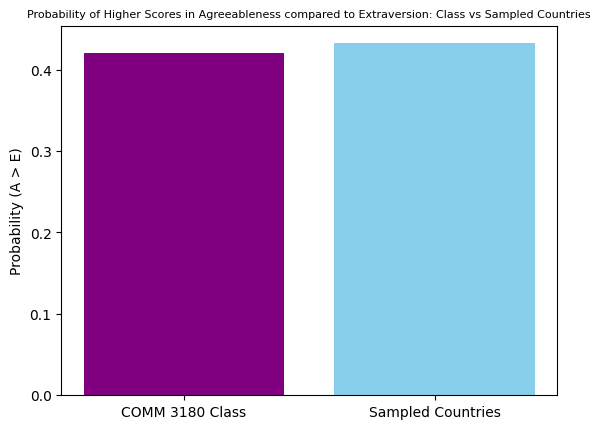

In [307]:
import matplotlib.pyplot as plt

labels = ['COMM 3180 Class', 'Sampled Countries']
values = [A_GT_E_class_prob, A_GT_E_prob]

plt.bar(labels, values)
plt.bar(labels, values, color=['purple', 'skyblue'])
plt.ylabel('Probability (A > E)')
plt.title('Probability of Higher Scores in Agreeableness compared to Extraversion: Class vs Sampled Countries',fontsize=8)

* This visualization compares the probability that respondants scored higher in Agreeableness as opposed to Extraversion in the COMM 3180 class and the Sampled Countries. Here we can clearly see that there is little difference in the probabilities which suggests that our class reflects a similar pattern to the larger sample. However, in both groups, there was a greater probability of scoring in higher percentiles of extraversion. This similarity indicates that the trends observed in the global dataset may be somewhat generalizable to our class with the exception of sample size and possibily variation in responses. 